In [1]:
from __future__ import print_function
import os
import sys

# Temporary workaround for Windows OpenMP duplicate runtime initialization in notebooks.
# Must be set before importing torch/torchvision/numpy-linked libraries.
os.environ.setdefault("KMP_DUPLICATE_LIB_OK", "TRUE")

# Set up absolute path to the root of the project for importing custom modules.
sys.path.append(os.path.abspath("../.."))

# Import necessary torch libraries
import torch
import torch.optim as optim
import torchvision.transforms as transforms

# Import Model
from models.CNN.CNN_d import CNN

# Import utils
from utils.train_val_utils import train_and_evaluate
from utils.dataloader_utils import dataloader
from utils.display_image_utils import display_original_vs_augmented
from utils.show_best_model_utils import show_best_model
from utils.load_best_model_utils import load_best_model
from utils.retrieve_results_from_ckpt_utils import results_from_ckpt
from utils.plot_train_val_curve_utils import plot_training_curves

# Set random seed for reproducibility
torch.manual_seed(42)

In [2]:
use_cuda = True
print("CUDA available:", torch.cuda.is_available())
device = torch.device("cuda" if (use_cuda and torch.cuda.is_available()) else "cpu")
print(f"Using device: {device}")

CUDA available: True
Using device: cuda


In [3]:
# Tensor conversion
transform = transforms.Compose([
    transforms.ToTensor(),
])

# Load datasets and dataloaders without augmentation for training dataset
train_dataset, val_dataset, test_dataset, train_loader, val_loader, test_loader = dataloader(
    train_root="../../butterfly_anomaly_image_resized/final_dataset/train",
    val_root="../../butterfly_anomaly_image_resized/final_dataset/val",
    test_root="../../butterfly_anomaly_image_resized/final_dataset/test",
    transform_train=transform,
    transform_eval=transform,
    batch_size=32,
    num_workers=4
)

Classes: ['0_non-hybrid', '1_hybrid']
Class->idx: {'0_non-hybrid': 0, '1_hybrid': 1}
Total: 3538
Classes: ['0_non-hybrid', '1_hybrid']
Class->idx: {'0_non-hybrid': 0, '1_hybrid': 1}
Total: 442
Classes: ['0_non-hybrid', '1_hybrid']
Class->idx: {'0_non-hybrid': 0, '1_hybrid': 1}
Total: 444


Classes: ['0_non-hybrid', '1_hybrid']
Class->idx: {'0_non-hybrid': 0, '1_hybrid': 1}
Total: 3538
Classes: ['0_non-hybrid', '1_hybrid']
Class->idx: {'0_non-hybrid': 0, '1_hybrid': 1}
Total: 442
Classes: ['0_non-hybrid', '1_hybrid']
Class->idx: {'0_non-hybrid': 0, '1_hybrid': 1}
Total: 444


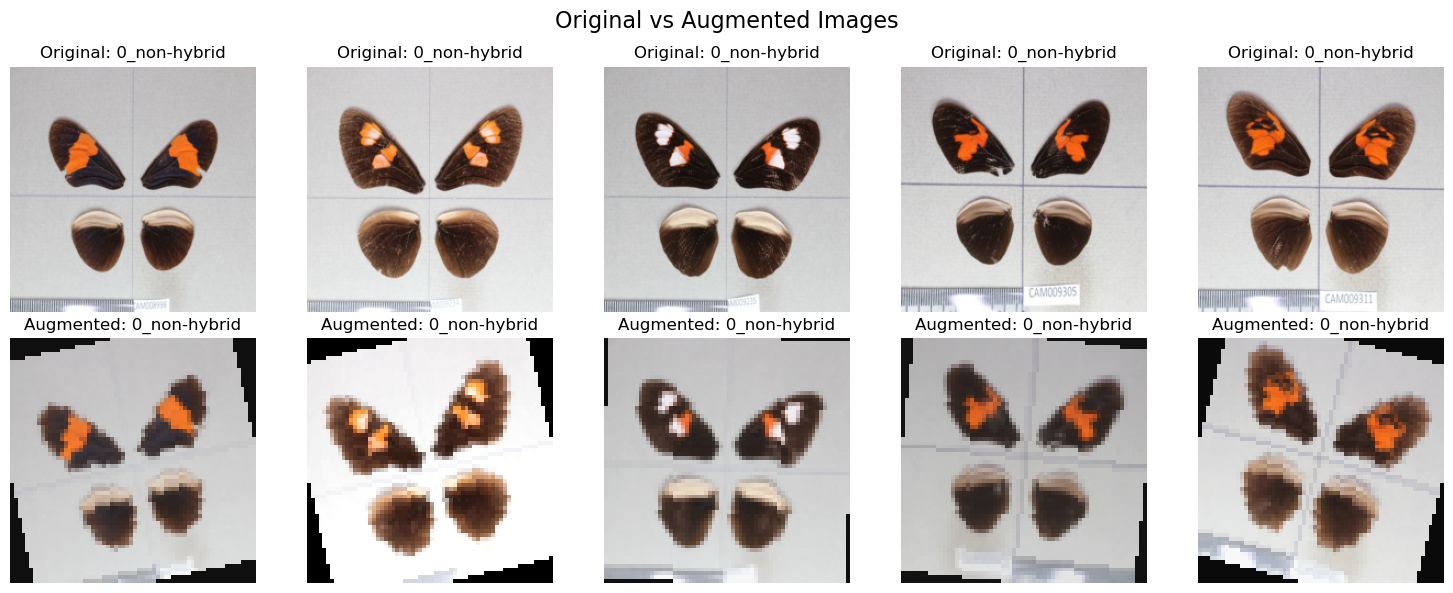

In [4]:
# Data augmentation transforms for training dataset
transform_train = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.RandomHorizontalFlip(0.5),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
])

# Data augmentation transforms for validation and test datasets (only resizing and tensor conversion)
transform_eval = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor(),
])

# Load datasets and dataloaders with augmentation for training dataset
train_dataset_aug, val_dataset, test_dataset, train_loader_aug, val_loader, test_loader = dataloader(
    train_root="../../butterfly_anomaly_image_resized/final_dataset/train",
    val_root="../../butterfly_anomaly_image_resized/final_dataset/val",
    test_root="../../butterfly_anomaly_image_resized/final_dataset/test",
    transform_train=transform_train,
    transform_eval=transform_eval,
    batch_size=32,
    num_workers=4
)

assert train_dataset_aug.class_to_idx == val_dataset.class_to_idx == test_dataset.class_to_idx

display_original_vs_augmented(train_dataset, train_dataset_aug)

In [ ]:
learning_rate_values = [0.01, 0.005, 0.001, 0.0001]
weight_decay_values = [1e-3, 1e-4, 1e-5, 1e-6]
class_weights_values = [2.5, 3.5, 4.5, 5.5]
batch_size_values = [16, 32, 64, 128]

model_cnn_d_dict = {}
optimizer_d_dict = {}
results_d_dict = {}
best_d_dict = {}
best_f2_d_dict = {}

count = 1

best_learning_rate_dict = {}
best_weight_decay_dict = {}
best_class_weights_val_dict = {}
best_batch_size_dict = {}

best_learning_rate = 0.01
best_weight_decay = 1e-3
best_class_weights_val = 2.5
best_batch_size = 16

best_f2 = float("-inf")

# Hyperparameter tuning loop for learning rate
for learning_rate in learning_rate_values:
    model_cnn_d_dict[f"model_cnn_d{count}"] = CNN(num_classes=2).to(device)
    optimizer_d_dict[f"optimizer_d{count}"] = optim.Adam(model_cnn_d_dict[f"model_cnn_d{count}"].parameters(), lr=learning_rate, weight_decay=best_weight_decay)
    print(f"\nTraining CNN Model D{count} with learning rate {learning_rate}")
    results_d_dict[f"results_d{count}"] = train_and_evaluate(model_cnn_d_dict[f"model_cnn_d{count}"], train_dataset_aug, val_dataset, optimizer_d_dict[f"optimizer_d{count}"], num_epochs=30, batch_size=best_batch_size, class_weights_val=best_class_weights_val, ckpt_file=f"saved_models/cnn/cnn_d/cnn_model_d{count}_log.pkl", device=device, num_workers=0)
    best_d_dict[f"best_d{count}"], best_f2_d_dict[f"best_f2_d{count}"] = show_best_model(model_cnn_d_dict[f"model_cnn_d{count}"], ckpt_file=f"../../saved_models/cnn/cnn_d/cnn_model_d{count}_log.pkl")
    best_learning_rate_dict[f"best_learning_rate_d{count}"] = learning_rate
    best_weight_decay_dict[f"best_weight_decay_d{count}"] = best_weight_decay
    best_class_weights_val_dict[f"best_class_weights_val_d{count}"] = best_class_weights_val
    best_batch_size_dict[f"best_batch_size_d{count}"] = best_batch_size
    count += 1
    if best_f2_d_dict[f"best_f2_d{count-1}"] > best_f2:
        best_learning_rate = learning_rate
        best_f2 = best_f2_d_dict[f"best_f2_d{count-1}"]

# Hyperparameter tuning loop for weight decay
for weight_decay in weight_decay_values[1:]:
    model_cnn_d_dict[f"model_cnn_d{count}"] = CNN(num_classes=2).to(device)
    optimizer_d_dict[f"optimizer_d{count}"] = optim.Adam(model_cnn_d_dict[f"model_cnn_d{count}"].parameters(), lr=best_learning_rate, weight_decay=weight_decay)
    print(f"\nTraining CNN Model D{count} with weight decay {weight_decay}")
    results_d_dict[f"results_d{count}"] = train_and_evaluate(model_cnn_d_dict[f"model_cnn_d{count}"], train_dataset_aug, val_dataset, optimizer_d_dict[f"optimizer_d{count}"], num_epochs=30, batch_size=best_batch_size, class_weights_val=best_class_weights_val, ckpt_file=f"saved_models/cnn/cnn_d/cnn_model_d{count}_log.pkl", device=device, num_workers=0)
    best_d_dict[f"best_d{count}"], best_f2_d_dict[f"best_f2_d{count}"] = show_best_model(model_cnn_d_dict[f"model_cnn_d{count}"], ckpt_file=f"../../saved_models/cnn/cnn_d/cnn_model_d{count}_log.pkl")
    best_learning_rate_dict[f"best_learning_rate_d{count}"] = best_learning_rate
    best_weight_decay_dict[f"best_weight_decay_d{count}"] = weight_decay
    best_class_weights_val_dict[f"best_class_weights_val_d{count}"] = best_class_weights_val
    best_batch_size_dict[f"best_batch_size_d{count}"] = best_batch_size
    count += 1
    if best_f2_d_dict[f"best_f2_d{count-1}"] > best_f2:
        best_weight_decay = weight_decay
        best_f2 = best_f2_d_dict[f"best_f2_d{count-1}"]

# Hyperparameter tuning loop for class weights
for class_weights_val in class_weights_values[1:]:
    model_cnn_d_dict[f"model_cnn_d{count}"] = CNN(num_classes=2).to(device)
    optimizer_d_dict[f"optimizer_d{count}"] = optim.Adam(model_cnn_d_dict[f"model_cnn_d{count}"].parameters(), lr=best_learning_rate, weight_decay=best_weight_decay)
    print(f"\nTraining CNN Model D{count} with class weights {class_weights_val}")
    results_d_dict[f"results_d{count}"] = train_and_evaluate(model_cnn_d_dict[f"model_cnn_d{count}"], train_dataset_aug, val_dataset, optimizer_d_dict[f"optimizer_d{count}"], num_epochs=30, batch_size=best_batch_size, class_weights_val=class_weights_val, ckpt_file=f"saved_models/cnn/cnn_d/cnn_model_d{count}_log.pkl", device=device, num_workers=0)
    best_d_dict[f"best_d{count}"], best_f2_d_dict[f"best_f2_d{count}"] = show_best_model(model_cnn_d_dict[f"model_cnn_d{count}"], ckpt_file=f"../../saved_models/cnn/cnn_d/cnn_model_d{count}_log.pkl")
    best_learning_rate_dict[f"best_learning_rate_d{count}"] = best_learning_rate
    best_weight_decay_dict[f"best_weight_decay_d{count}"] = best_weight_decay
    best_class_weights_val_dict[f"best_class_weights_val_d{count}"] = class_weights_val
    best_batch_size_dict[f"best_batch_size_d{count}"] = best_batch_size
    count += 1
    if best_f2_d_dict[f"best_f2_d{count-1}"] > best_f2:
        best_class_weights_val = class_weights_val
        best_f2 = best_f2_d_dict[f"best_f2_d{count-1}"]

# Hyperparameter tuning loop for batch size
for batch_size in batch_size_values[1:]:
    model_cnn_d_dict[f"model_cnn_d{count}"] = CNN(num_classes=2).to(device)
    optimizer_d_dict[f"optimizer_d{count}"] = optim.Adam(model_cnn_d_dict[f"model_cnn_d{count}"].parameters(), lr=best_learning_rate, weight_decay=best_weight_decay)
    print(f"\nTraining CNN Model D{count} with batch size {batch_size}")
    results_d_dict[f"results_d{count}"] = train_and_evaluate(model_cnn_d_dict[f"model_cnn_d{count}"], train_dataset_aug, val_dataset, optimizer_d_dict[f"optimizer_d{count}"], num_epochs=30, batch_size=batch_size, class_weights_val=best_class_weights_val, ckpt_file=f"saved_models/cnn/cnn_d/cnn_model_d{count}_log.pkl", device=device, num_workers=0)
    best_d_dict[f"best_d{count}"], best_f2_d_dict[f"best_f2_d{count}"] = show_best_model(model_cnn_d_dict[f"model_cnn_d{count}"], ckpt_file=f"../../saved_models/cnn/cnn_d/cnn_model_d{count}_log.pkl")
    best_learning_rate_dict[f"best_learning_rate_d{count}"] = best_learning_rate
    best_weight_decay_dict[f"best_weight_decay_d{count}"] = best_weight_decay
    best_class_weights_val_dict[f"best_class_weights_val_d{count}"] = best_class_weights_val
    best_batch_size_dict[f"best_batch_size_d{count}"] = batch_size
    count += 1
    if best_f2_d_dict[f"best_f2_d{count-1}"] > best_f2:
        best_batch_size = batch_size
        best_f2 = best_f2_d_dict[f"best_f2_d{count-1}"]


Training CNN Model D1 with learning rate 0.01
  [Epoch 1] Improvement! New best score: 0.601318
  [Epoch 3] Improvement! New best score: 0.779070
  [Epoch 4] Improvement! New best score: 0.795964
  [Epoch 5] Improvement! New best score: 0.810811
Epoch [5/30], Train Loss: 0.3672, Val Loss: 0.2547, Train F1-Macro: 0.8123, Val F1-Macro: 0.8108, Train F1-Per-Class: [0.921095  0.7034297], Val F1-Per-Class: [0.9195402  0.70212764], Train F2-Macro: 0.8490, Val F2-Macro: 0.8491, Train F2-Per-Class: [0.8905958  0.80734795], Val F2-Per-Class: [0.88740987 0.8108108 ], No improvement: 0/6
Epoch [5/30], Epoch [5/30], Train Loss: 0.3672, Val Loss: 0.2547, Train F1-Macro: 0.8123, Val F1-Macro: 0.8108, Train F1-Per-Class: [0.921095  0.7034297], Val F1-Per-Class: [0.9195402  0.70212764] Train F2-Macro: 0.8490, Val F2-Macro: 0.8491, Train F2-Per-Class: [0.8905958  0.80734795], Val F2-Per-Class: [0.88740987 0.8108108 ]
Epoch [10/30], Train Loss: 0.3503, Val Loss: 0.4053, Train F1-Macro: 0.7139, Val F1-M

In [5]:
# Restore best hyperparameters for model_d
best_learning_rate_dict = {'best_learning_rate_d1': 0.01, 'best_learning_rate_d2': 0.005, 'best_learning_rate_d3': 0.001, 'best_learning_rate_d4': 0.0001, 'best_learning_rate_d5': 0.0001, 'best_learning_rate_d6': 0.0001, 'best_learning_rate_d7': 0.0001, 'best_learning_rate_d8': 0.0001, 'best_learning_rate_d9': 0.0001, 'best_learning_rate_d10': 0.0001, 'best_learning_rate_d11': 0.0001, 'best_learning_rate_d12': 0.0001, 'best_learning_rate_d13': 0.0001}
best_weight_decay_dict = {'best_weight_decay_d1': 0.001, 'best_weight_decay_d2': 0.001, 'best_weight_decay_d3': 0.001, 'best_weight_decay_d4': 0.001, 'best_weight_decay_d5': 0.0001, 'best_weight_decay_d6': 1e-05, 'best_weight_decay_d7': 1e-06, 'best_weight_decay_d8': 0.0001, 'best_weight_decay_d9': 0.0001, 'best_weight_decay_d10': 0.0001, 'best_weight_decay_d11': 0.0001, 'best_weight_decay_d12': 0.0001, 'best_weight_decay_d13': 0.0001}
best_class_weights_val_dict = {'best_class_weights_val_d1': 2.5, 'best_class_weights_val_d2': 2.5, 'best_class_weights_val_d3': 2.5, 'best_class_weights_val_d4': 2.5, 'best_class_weights_val_d5': 2.5, 'best_class_weights_val_d6': 2.5, 'best_class_weights_val_d7': 2.5, 'best_class_weights_val_d8': 3.5, 'best_class_weights_val_d9': 4.5, 'best_class_weights_val_d10': 5.5, 'best_class_weights_val_d11': 3.5, 'best_class_weights_val_d12': 3.5, 'best_class_weights_val_d13': 3.5}
best_batch_size_dict = {'best_batch_size_d1': 16, 'best_batch_size_d2': 16, 'best_batch_size_d3': 16, 'best_batch_size_d4': 16, 'best_batch_size_d5': 16, 'best_batch_size_d6': 16, 'best_batch_size_d7': 16, 'best_batch_size_d8': 16, 'best_batch_size_d9': 16, 'best_batch_size_d10': 16, 'best_batch_size_d11': 32, 'best_batch_size_d12': 64, 'best_batch_size_d13': 128}

# Initialize model_cnn_d_dict with CNN instances for each hyperparameter combination
model_cnn_d_dict = {
    'model_cnn_d1': CNN(num_classes=2).to(device),
    'model_cnn_d2': CNN(num_classes=2).to(device),
    'model_cnn_d3': CNN(num_classes=2).to(device),
    'model_cnn_d4': CNN(num_classes=2).to(device),
    'model_cnn_d5': CNN(num_classes=2).to(device),
    'model_cnn_d6': CNN(num_classes=2).to(device),
    'model_cnn_d7': CNN(num_classes=2).to(device),
    'model_cnn_d8': CNN(num_classes=2).to(device),
    'model_cnn_d9': CNN(num_classes=2).to(device),
    'model_cnn_d10': CNN(num_classes=2).to(device),
    'model_cnn_d11': CNN(num_classes=2).to(device),
    'model_cnn_d12': CNN(num_classes=2).to(device),
    'model_cnn_d13': CNN(num_classes=2).to(device)
}

best_d_dict = {}
best_f2_d_dict = {}

In [6]:
for i in range(1, 8):
    print(
        f"Model D{i} | "
        f"lr={best_learning_rate_dict[f'best_learning_rate_d{i}']} | "
        f"wd={best_weight_decay_dict[f'best_weight_decay_d{i}']} | "
        f"class_w={best_class_weights_val_dict[f'best_class_weights_val_d{i}']} | "
        f"bs={best_batch_size_dict[f'best_batch_size_d{i}']} | "
    )
    best_d_dict[f"best_d{i}"], best_f2_d_dict[f"best_f2_d{i}"] = show_best_model(model=model_cnn_d_dict[f"model_cnn_d{i}"], ckpt_file=f"../../saved_models/cnn/cnn_d/cnn_model_d{i}_log.pkl")

Model D1 | lr=0.01 | wd=0.001 | class_w=2.5 | bs=16 | 
Selected epoch: 5
Best val F2(class 0): 0.8874098658561707
Best val F2(class 1): 0.8108108043670654
Model D2 | lr=0.005 | wd=0.001 | class_w=2.5 | bs=16 | 
Selected epoch: 23
Best val F2(class 0): 0.9810298085212708
Best val F2(class 1): 0.9041095972061157
Model D3 | lr=0.001 | wd=0.001 | class_w=2.5 | bs=16 | 
Selected epoch: 10
Best val F2(class 0): 0.9711642861366272
Best val F2(class 1): 0.9139785170555115
Model D4 | lr=0.0001 | wd=0.001 | class_w=2.5 | bs=16 | 
Selected epoch: 10
Best val F2(class 0): 0.9826275706291199
Best val F2(class 1): 0.9375
Model D5 | lr=0.0001 | wd=0.0001 | class_w=2.5 | bs=16 | 
Selected epoch: 20
Best val F2(class 0): 0.9831613302230835
Best val F2(class 1): 0.9485095143318176
Model D6 | lr=0.0001 | wd=1e-05 | class_w=2.5 | bs=16 | 
Selected epoch: 7
Best val F2(class 0): 0.9540732502937317
Best val F2(class 1): 0.9055117964744568
Model D7 | lr=0.0001 | wd=1e-06 | class_w=2.5 | bs=16 | 
Selected epo

In [7]:
for i in range(8, 14):
    print(
        f"Model D{i} | "
        f"lr={best_learning_rate_dict[f'best_learning_rate_d{i}']} | "
        f"wd={best_weight_decay_dict[f'best_weight_decay_d{i}']} | "
        f"class_w={best_class_weights_val_dict[f'best_class_weights_val_d{i}']} | "
        f"bs={best_batch_size_dict[f'best_batch_size_d{i}']} | "
    )
    best_d_dict[f"best_d{i}"], best_f2_d_dict[f"best_f2_d{i}"] = show_best_model(model=model_cnn_d_dict[f"model_cnn_d{i}"], ckpt_file=f"../../saved_models/cnn/cnn_d/cnn_model_d{i}_log.pkl")

Model D8 | lr=0.0001 | wd=0.0001 | class_w=3.5 | bs=16 | 
Selected epoch: 20
Best val F2(class 0): 0.9815117120742798
Best val F2(class 1): 0.9568732976913452
Model D9 | lr=0.0001 | wd=0.0001 | class_w=4.5 | bs=16 | 
Selected epoch: 10
Best val F2(class 0): 0.9705561399459839
Best val F2(class 1): 0.9441489577293396
Model D10 | lr=0.0001 | wd=0.0001 | class_w=5.5 | bs=16 | 
Selected epoch: 16
Best val F2(class 0): 0.9683578610420227
Best val F2(class 1): 0.941644549369812
Model D11 | lr=0.0001 | wd=0.0001 | class_w=3.5 | bs=32 | 
Selected epoch: 10
Best val F2(class 0): 0.956807017326355
Best val F2(class 1): 0.9186351895332336
Model D12 | lr=0.0001 | wd=0.0001 | class_w=3.5 | bs=64 | 
Selected epoch: 4
Best val F2(class 0): 0.8769487738609314
Best val F2(class 1): 0.8212560415267944
Model D13 | lr=0.0001 | wd=0.0001 | class_w=3.5 | bs=128 | 
Selected epoch: 15
Best val F2(class 0): 0.9501643180847168
Best val F2(class 1): 0.9114583134651184


In [8]:
# Pick the model index with highest validation F2 (class 1) among all collected runs
best_f2_key = max(best_f2_d_dict, key=lambda k: float(best_f2_d_dict[k]))
best_i = int(best_f2_key.split("d")[-1])

model = model_cnn_d_dict[f"model_cnn_d{best_i}"]
best = best_d_dict[f"best_d{best_i}"]

print(
    f"Selected Best Model D{best_i} | "
    f"val_f2_class1={float(best_f2_d_dict[best_f2_key]):.6f} | "
    f"lr={best_learning_rate_dict[f'best_learning_rate_d{best_i}']} | "
    f"wd={best_weight_decay_dict[f'best_weight_decay_d{best_i}']} | "
    f"class_w={best_class_weights_val_dict[f'best_class_weights_val_d{best_i}']} | "
    f"bs={best_batch_size_dict[f'best_batch_size_d{best_i}']}"
)

# Load the best model and evaluate on the test dataset
load_best_model(best_model=model, best=best, test_dataset=test_dataset, device=device)

Selected Best Model D8 | val_f2_class1=0.956873 | lr=0.0001 | wd=0.0001 | class_w=3.5 | bs=16
Test loss: 0.06653642006650833
Test F2 macro: 0.9662023782730103
Test F2 per class: [0.9832069 0.9491979]
Test F2 for class 1 (1_hybrid): 0.9491978883743286


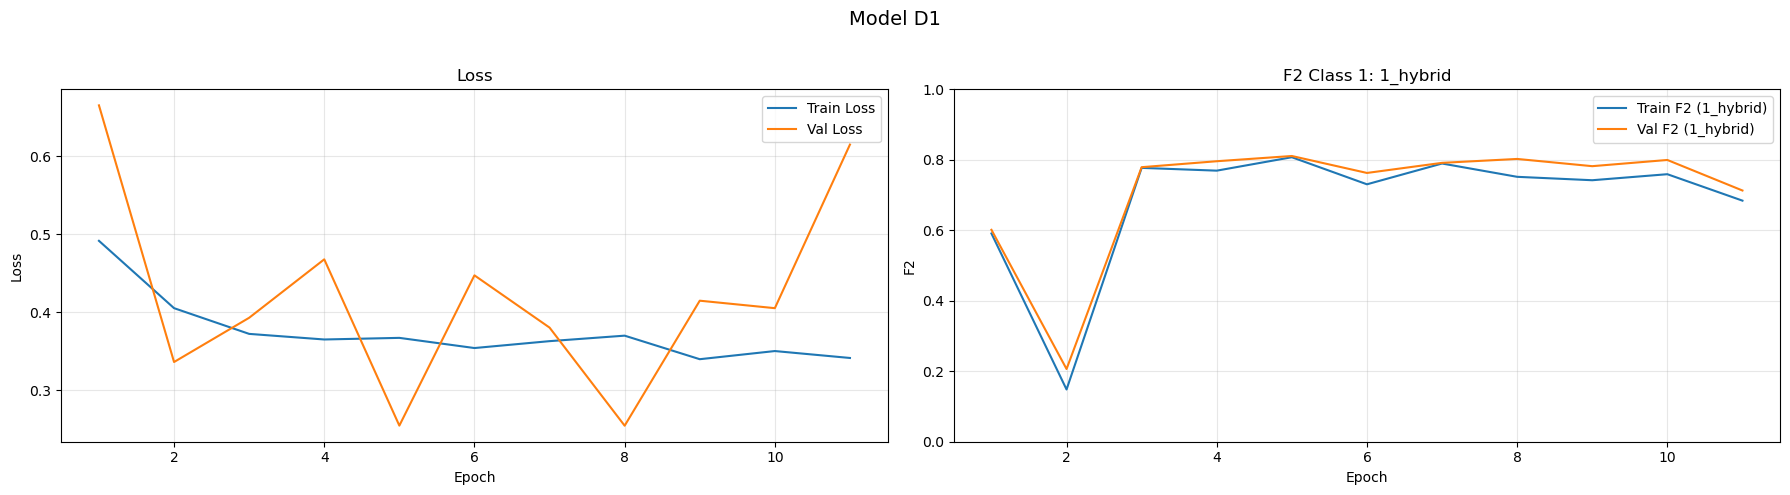

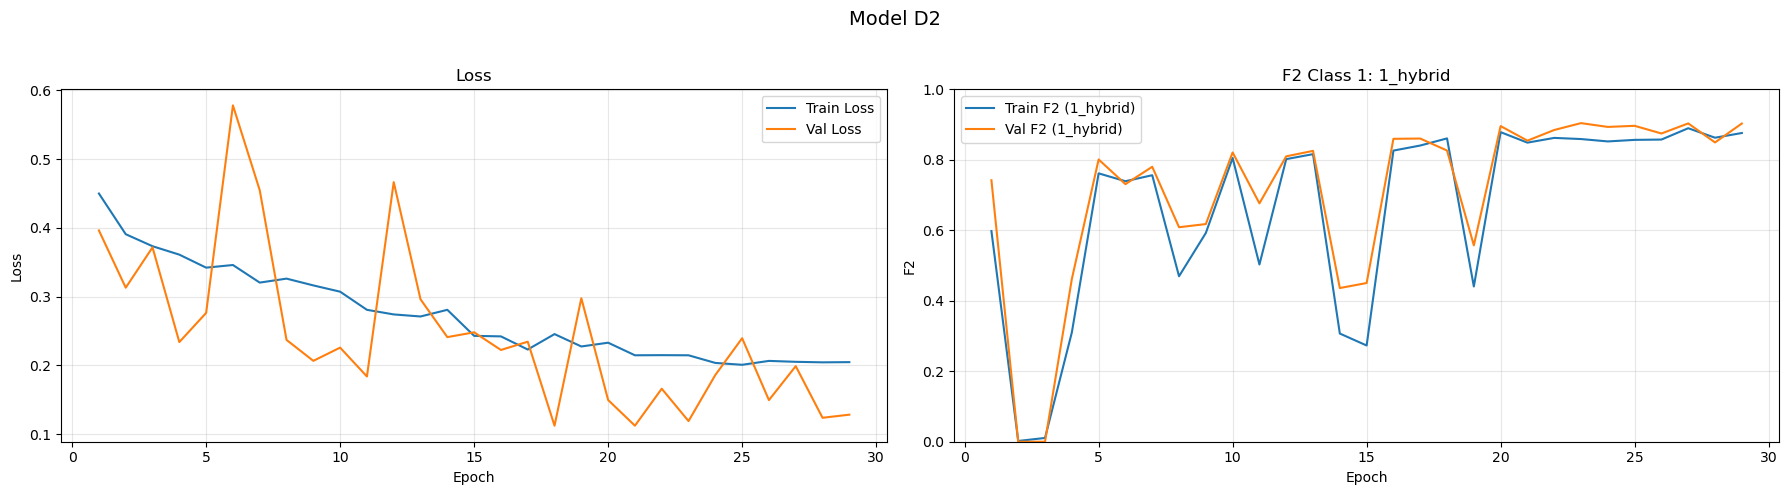

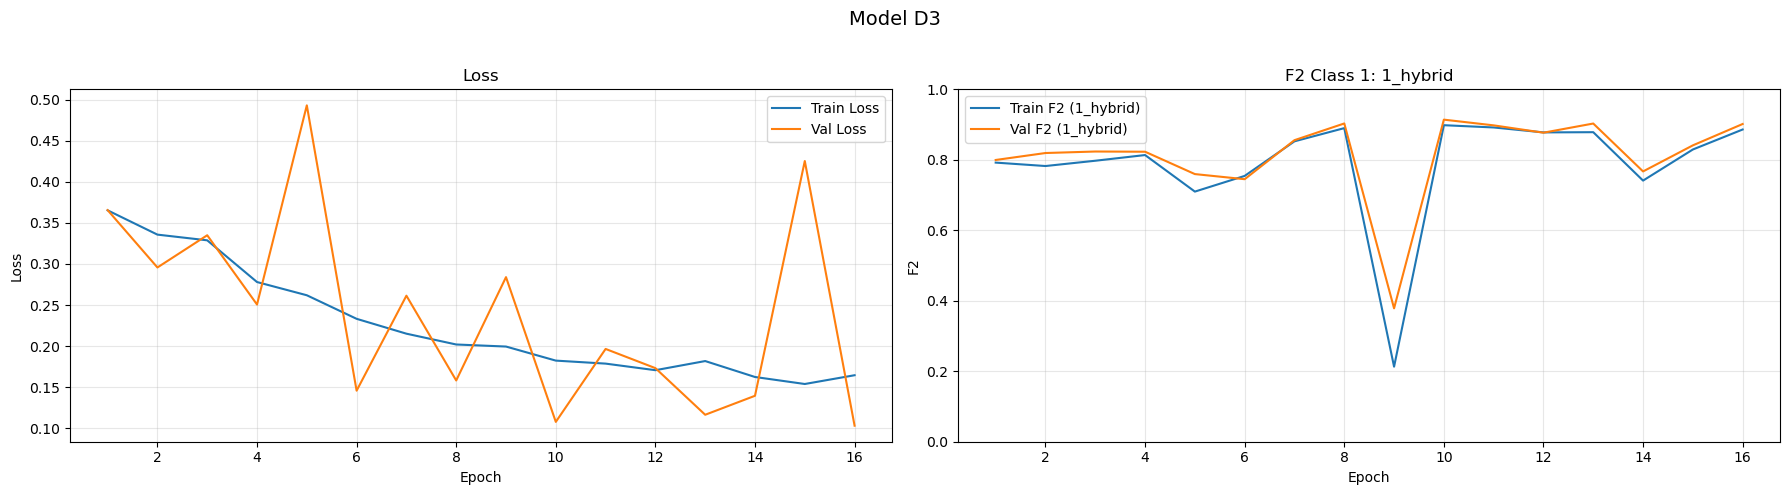

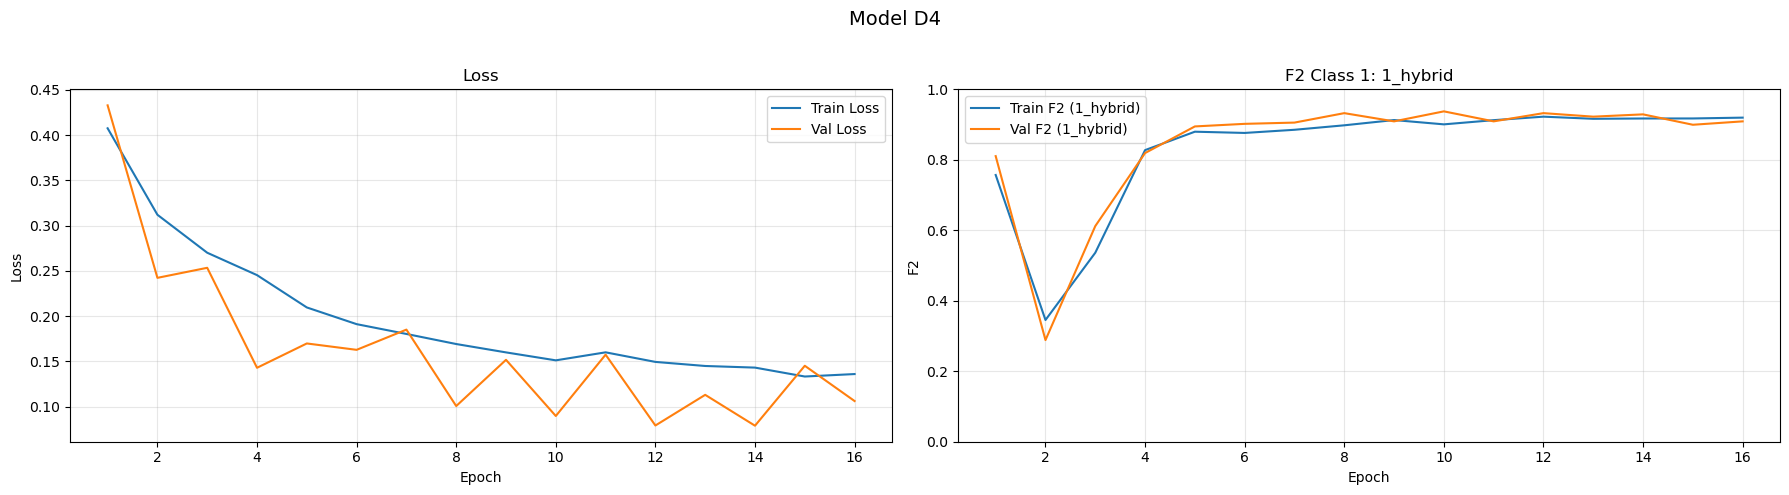

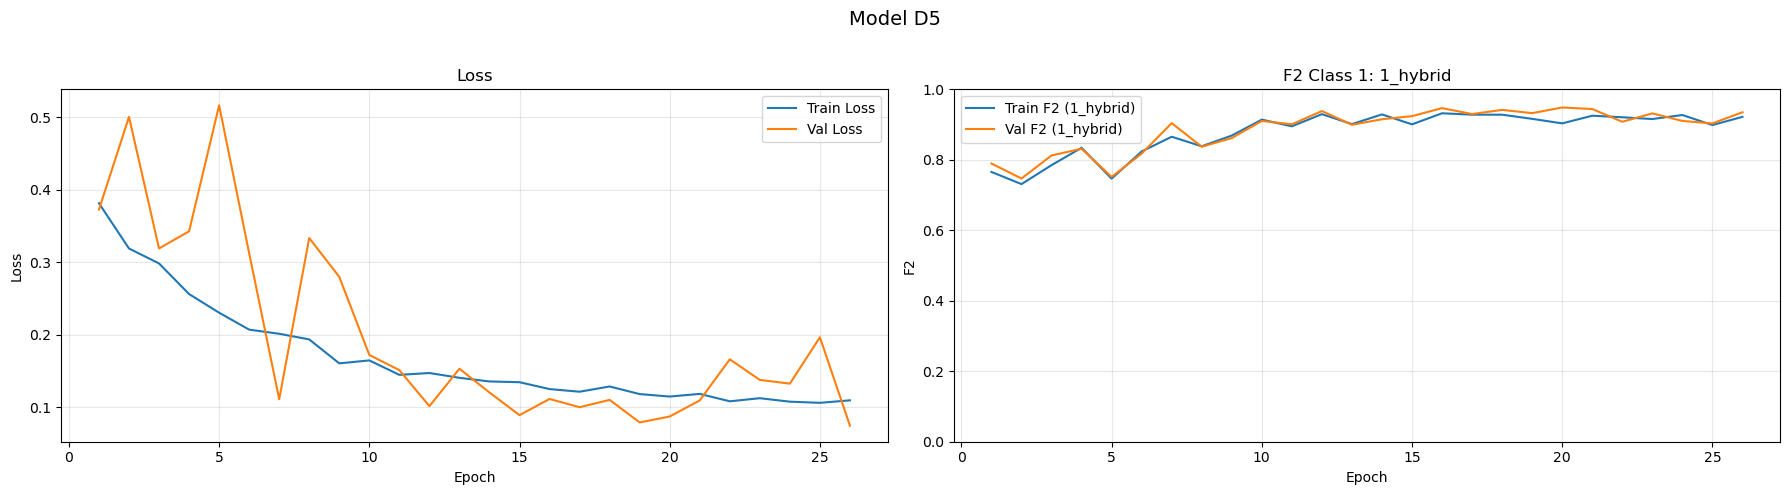

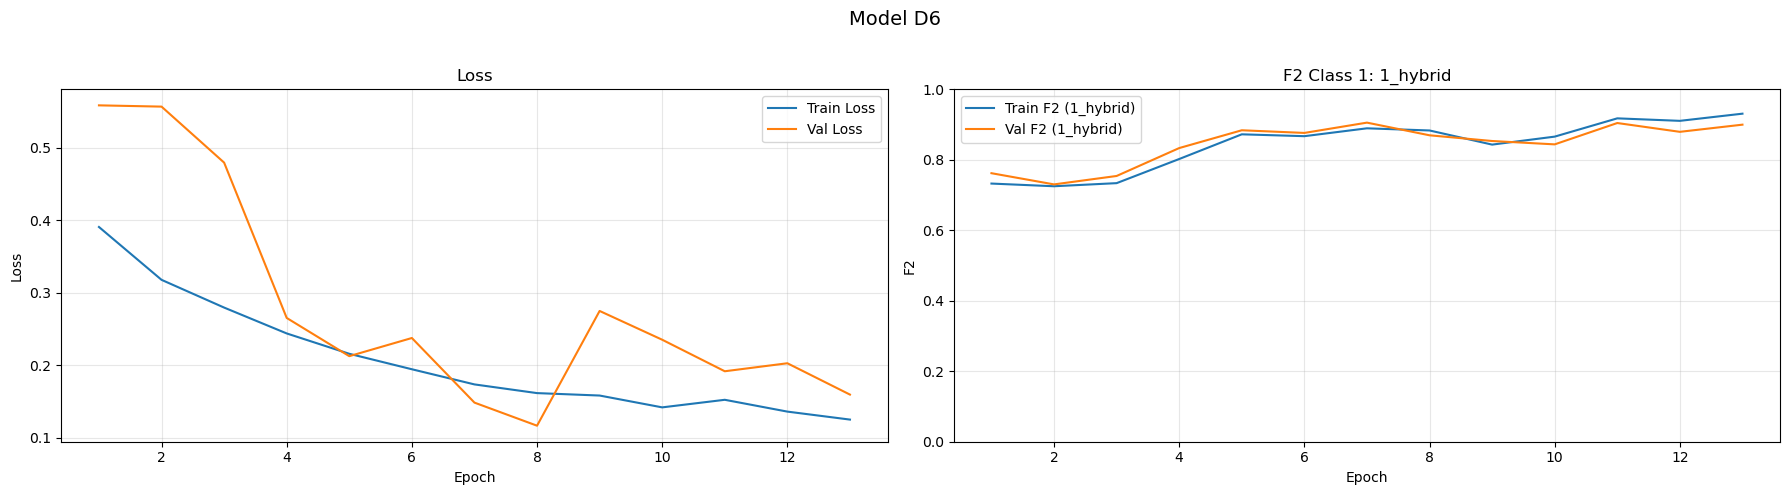

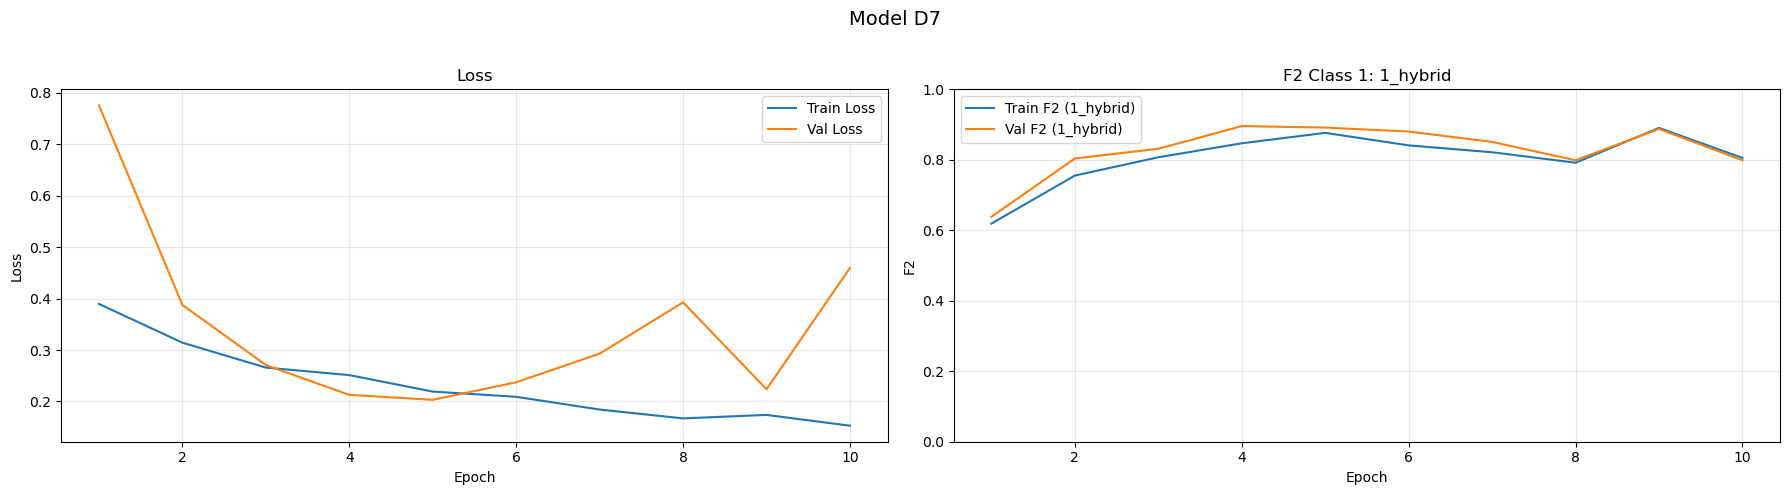

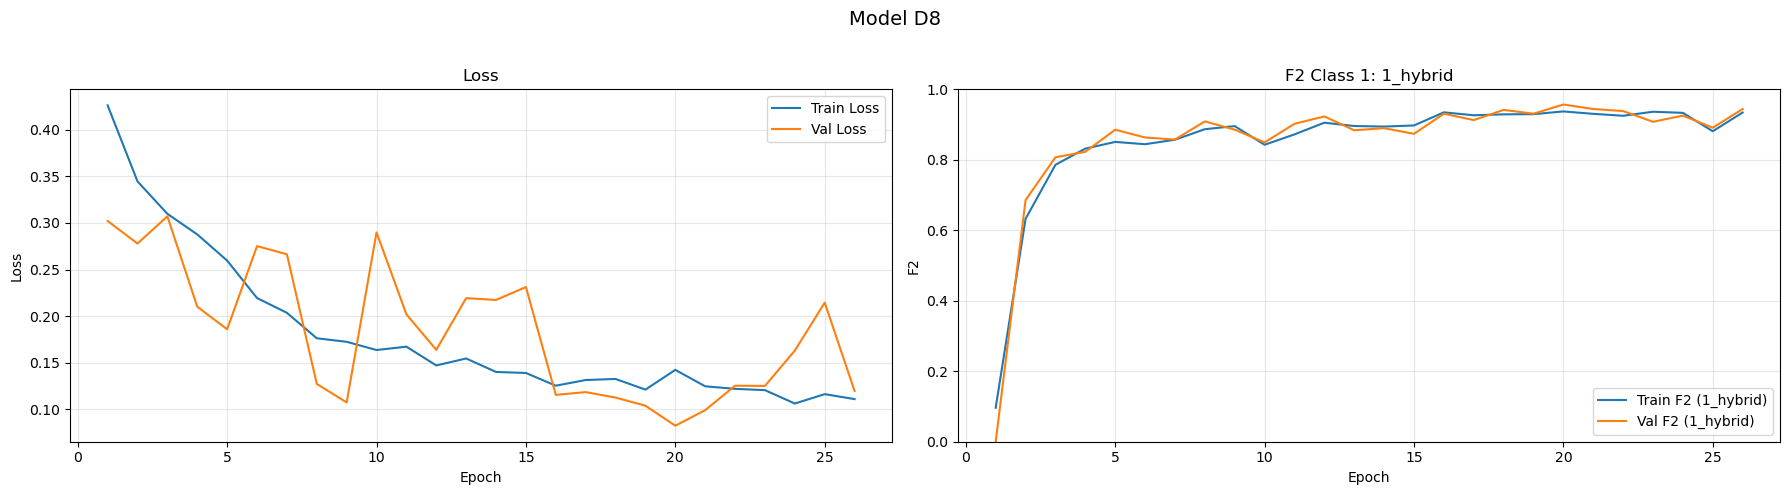

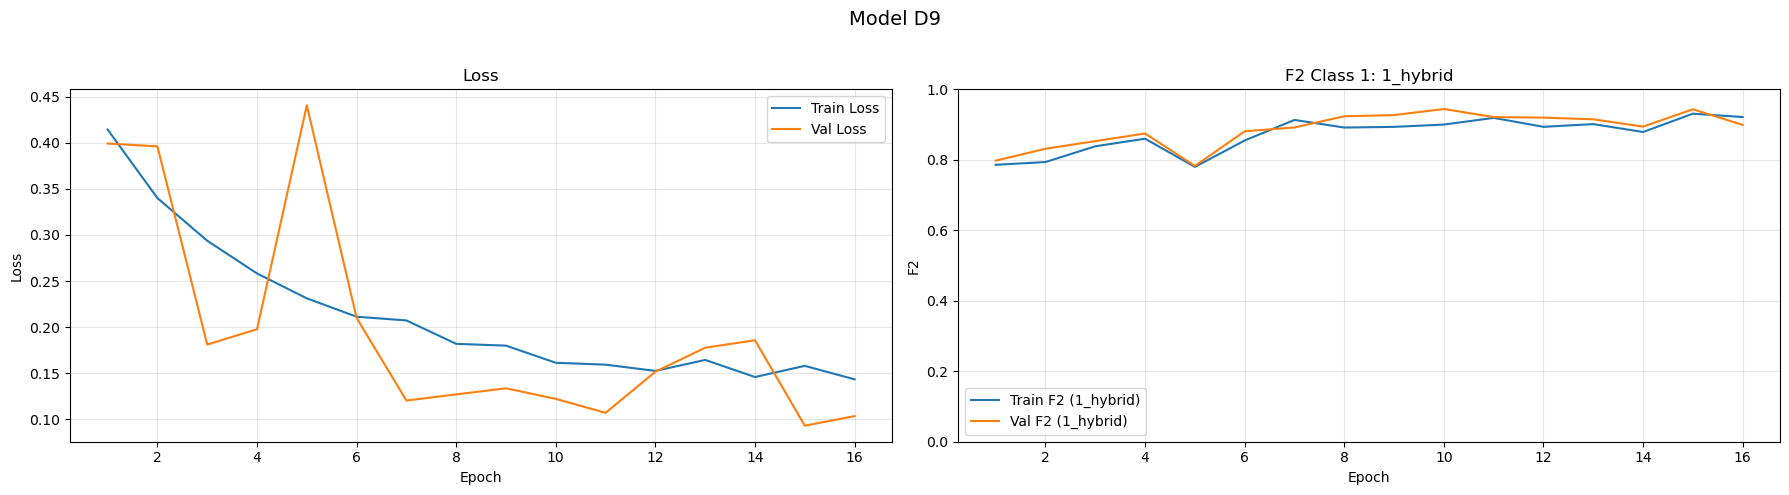

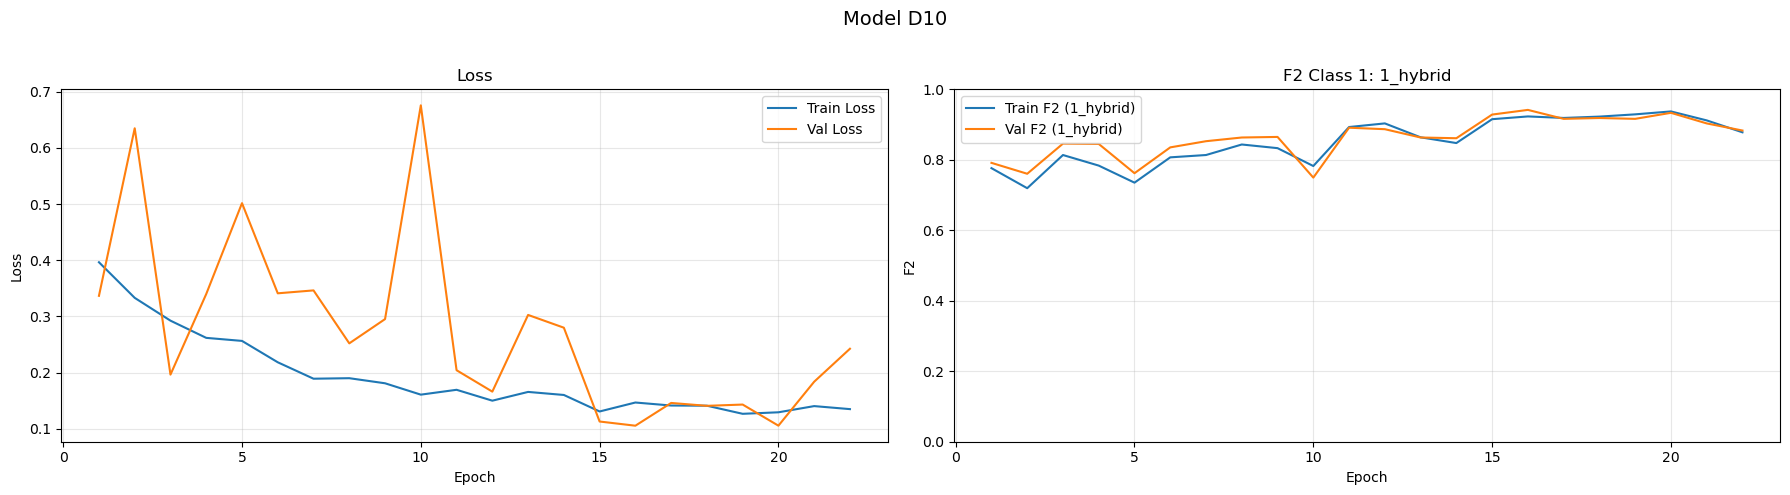

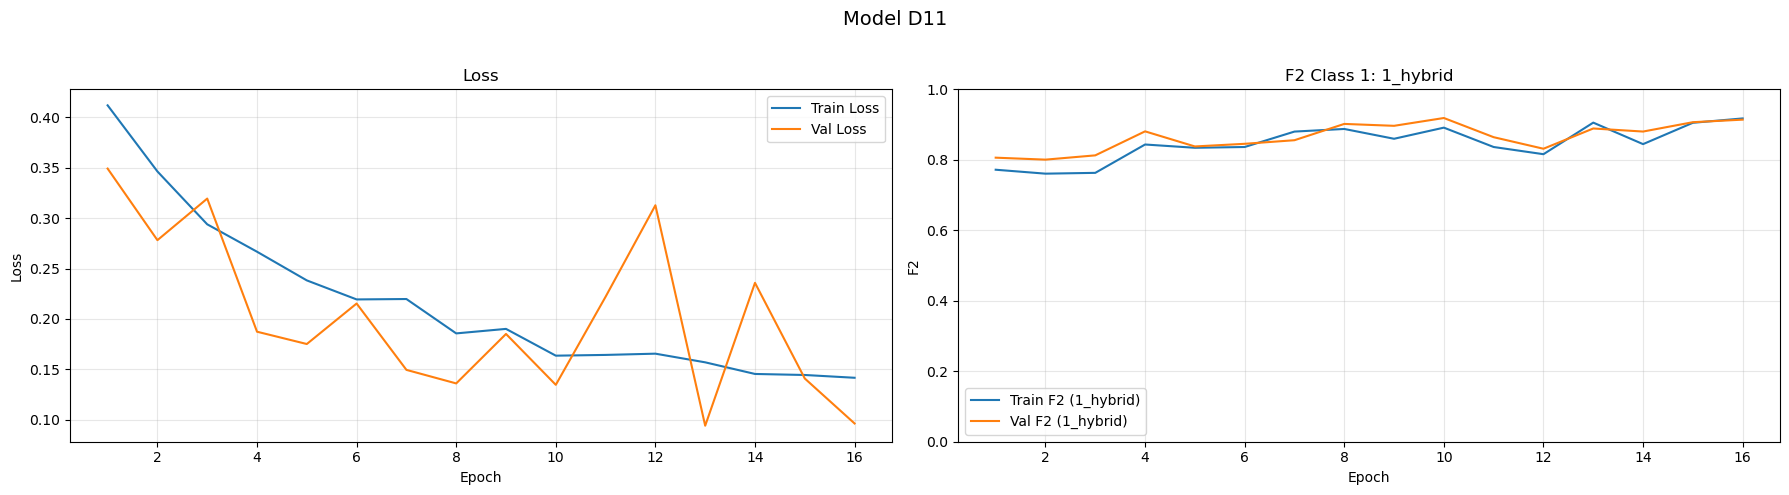

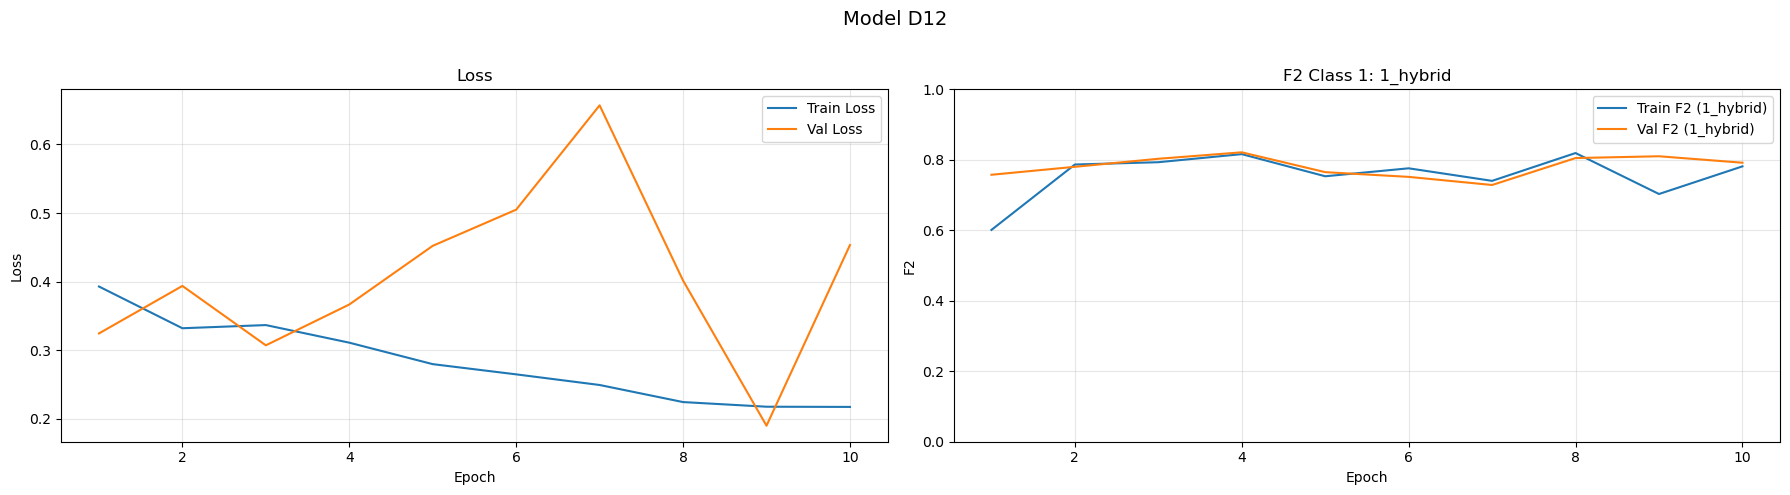

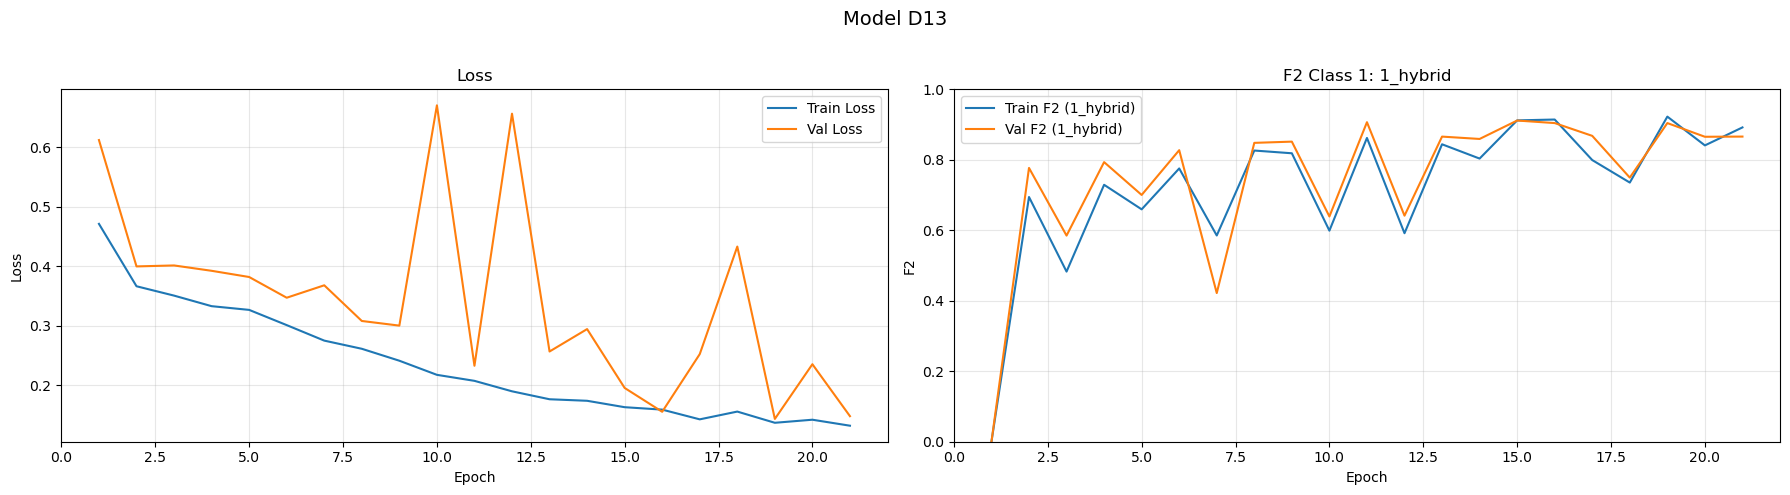

In [9]:
for i in range(1, 14):
    plot_training_curves(model_name=f"Model D{i}", results=results_from_ckpt(model=model_cnn_d_dict[f"model_cnn_d{i}"], ckpt_file=f"../../saved_models/cnn/cnn_d/cnn_model_d{i}_log.pkl"), class_idx=1, class_name="1_hybrid")